In [1]:
from keypoint_dataset import KeypointDataset
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import torch

In [2]:
datasetPath = "/home/giorgio6846/Code/Sign-AI/data/dataset1.hdf5"
kd = KeypointDataset(datasetPath, return_label=True)

In [3]:
len(kd)

8459

In [4]:
keypoints = kd[4000][0].clone()

In [5]:
minValue = 999999
maxValue = -99999

for idx in range(len(kd)):
    keypoints_frames = kd[idx][0].shape[0]
    minValue = min(keypoints_frames, minValue)
    maxValue = max(keypoints_frames, maxValue)

print(minValue)
print(maxValue)

5
2695


In [6]:
keypoints.shape

torch.Size([500, 250, 2])

In [ ]:
def filter_unstable_keypoints_1(keypoints, threshold_var=0.008):
    """
    Elimina keypoints que se mueven erráticamente o aparecen esporádicamente.
    - threshold_var: varianza máxima aceptada para un keypoint estable.
    """
    T, N, _ = keypoints.shape

    # 1. Varianza temporal por keypoint
    var = keypoints.var(dim=0).mean(dim=1)  # (N,)
    stable_mask = var < threshold_var
    # 4. Aplicar la máscara
    filtered = keypoints.clone()
    for i in range(N):
        if not stable_mask[i]:
            filtered[:, i] = 0  # o NaN

    return filtered, stable_mask

# Usar clip 4000 como ejemplo
keypoints_raw = kd[4000][0].clone()
keypoints_filtered, final_mask = filter_unstable_keypoints_1(keypoints_raw)

print(f"Total keypoints: {final_mask.numel()}")
print(f"Conservados: {final_mask.sum().item()}")
print(f"Eliminados: {(~final_mask).sum().item()}")


Total keypoints: 250
Conservados: 230
Eliminados: 20


In [55]:
def filter_unstable_keypoints_to_num(keypoints, keep_n=230):
    """
    Conserva los 'keep_n' keypoints más estables (con menor varianza temporal).
    """
    T, N, _ = keypoints.shape

    # Calcular varianza temporal por keypoint
    var = keypoints.var(dim=0).mean(dim=1)  # (N,)

    # Obtener los índices de los keypoints más estables
    _, indices = torch.topk(-var, k=keep_n)  # usamos -var para orden ascendente
    stable_mask = torch.zeros(N, dtype=torch.bool)
    stable_mask[indices] = True

    # Aplicar la máscara
    filtered = keypoints.clone()
    for i in range(N):
        if not stable_mask[i]:
            filtered[:, i] = 0

    return filtered, stable_mask


In [56]:

keypoints_f, _ = filter_unstable_keypoints_to_num(keypoints)


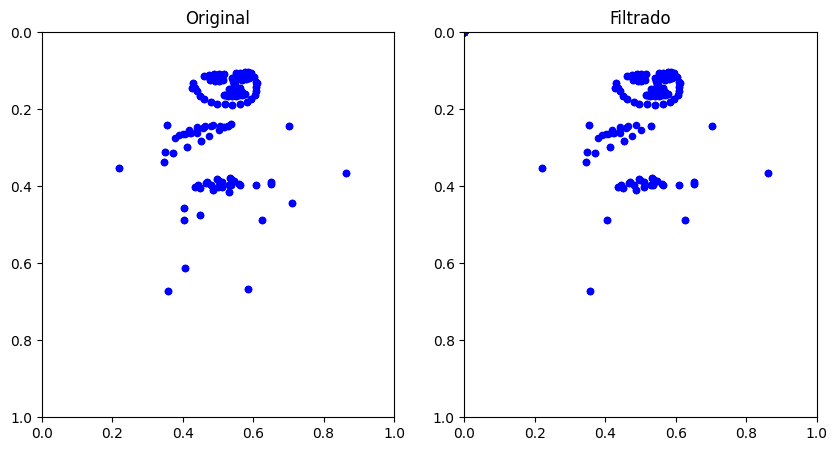

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].set_title("Original")
axs[1].set_title("Filtrado")

sc1 = axs[0].scatter(keypoints[0, :, 0], keypoints[0, :, 1], s=20, c='blue')

sc2 = axs[1].scatter(keypoints_f[0, :, 0], keypoints_f[0, :, 1], s=20, c='blue')

for ax in axs:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()




In [58]:
def update(frame_index):
    points = keypoints[frame_index]       # [250, 2]
    filter_points = keypoints_f[frame_index]    # [250, 2]
    sc1.set_offsets(points)           # Move every scatter point to new coords
    sc2.set_offsets(filter_points)           # Move every scatter point to new coords
    axs[0].set_title(f"Frame {frame_index} Original")
    axs[1].set_title(f"Frame {frame_index} filtrado")
    return sc1, sc2

In [59]:
anim = FuncAnimation(
    fig,
    update,
    frames=keypoints.shape[0],  # 148
    interval=50,             # 50 ms between frames (≈20 FPS)
    blit=True
)

HTML(anim.to_jshtml())
